In [114]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from saqc import SaQC
import metpyqc as qc

from qc_func import *
from visualizaion_func import *

In [116]:
import sqlalchemy as sa
from sqlalchemy.orm import Session
from crmprtd import setup_logging
from pycds import Station, History

save_path = './comparison_forms/'

db_url = "postgresql://tongli1997@db.pcic.uvic.ca:5433/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"
log_file_path = save_path

engine = sa.create_engine(db_url, echo=False)
session = Session(engine)

session

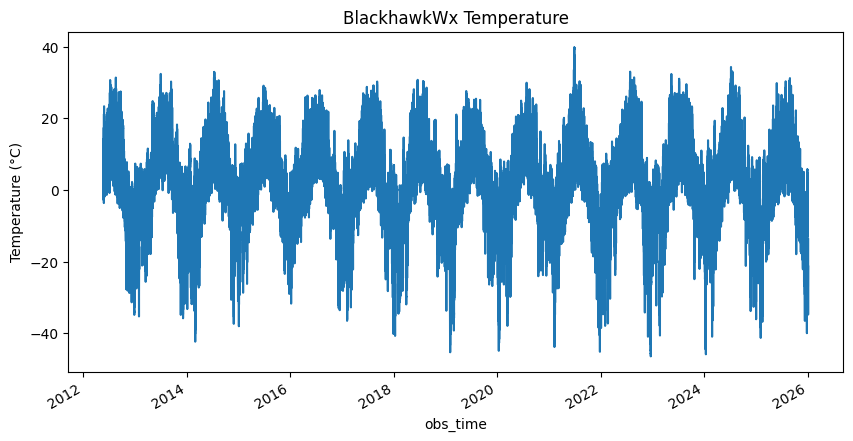

In [117]:
sql_text = sa.text("""
SELECT Distinct o.obs_time, o.datum
FROM meta_history h
JOIN meta_station s ON h.station_id = s.station_id
JOIN obs_raw o ON o.history_id = h.history_id
JOIN meta_vars v ON o.vars_id = v.vars_id
WHERE s.network_id = 11
AND h.station_name = 'BlackhawkWx'
AND v.net_var_name = 'TempC'
""")

with engine.begin() as conn:
    df = pd.read_sql(sql_text, conn)
df = df.rename(columns={'datum': 'temp'})

# convert to datetime
df["obs_time"] = pd.to_datetime(df["obs_time"])

# set as index
df = df.set_index("obs_time").sort_index()

# plot
df["temp"].plot(figsize=(10,5))
plt.ylabel("Temperature (°C)")
plt.title("BlackhawkWx Temperature")
plt.show()


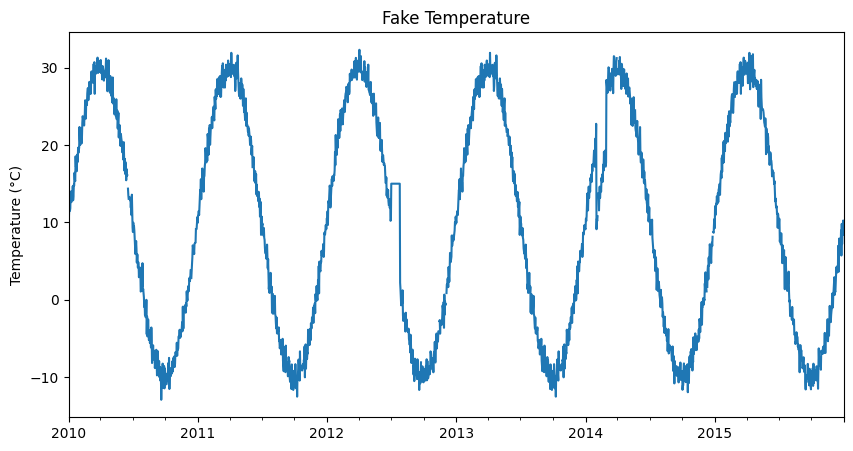

In [ ]:
### Import a fake data
from fake_data_design import *
df_test = create_integrity_test_temperature_df()
df_test["temp"].plot(figsize=(10,5))

plt.ylabel("Temperature (°C)")
plt.title("Fake Temperature")
plt.show()



### Missing value check

In [119]:
miss_result = check_missing_timestamps(df)

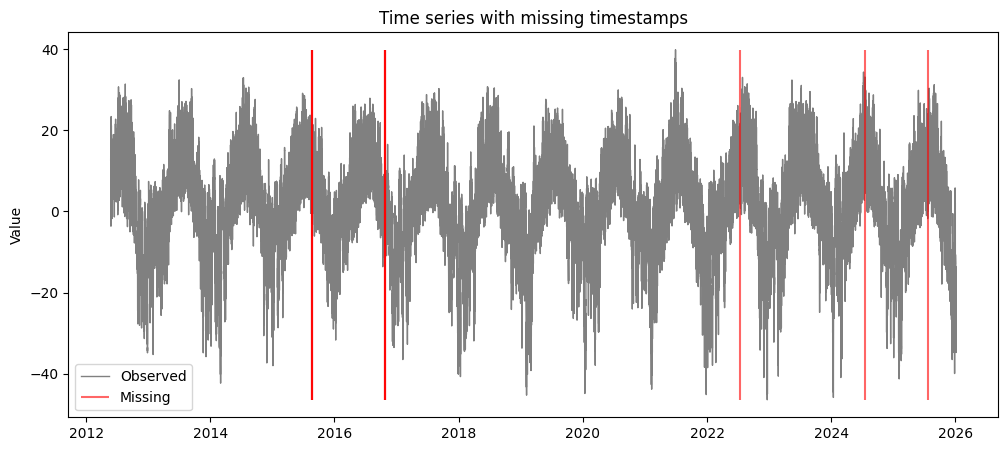

In [120]:
plot_timeseries_with_missing(
    df=df,
    missing_times=miss_result['missing_times']
)

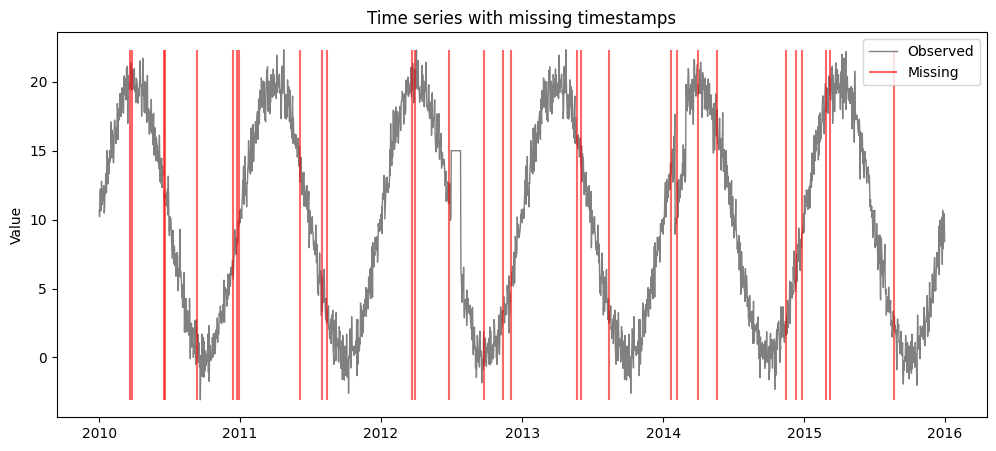

In [121]:
miss_result_test = check_missing_timestamps(df_test)

plot_timeseries_with_missing(
    df=df_test,
    missing_times=miss_result_test['missing_times']
)

### Duplicate check

Check for
1. Duplicate entire years: “All values in one year = another year”
2. Duplicate months within the same year: “One month = another month”
3. Same calendar month across years: “Jan 2000 = Jan 2001”

4. Identical value–streak checks: •	If the same value repeats for many consecutive days, it’s unusual and probably an error.
	- Example thresholds given:
	- Temperature (TMAX/TMIN): 20 or more consecutive identical values
	- Snowfall (SNOW): 10 or more consecutive identical nonzero values
	- Snow depth (SNWD): 90 or more consecutive identical nonzero values

In [122]:
from dunplicate_check_func import *

dup_result = duplicate_check_temperature(df, column = 'temp')

print_duplicate_summary(dup_result)


===== DUPLICATE CHECK SUMMARY =====

📅 Duplicate Years: None

📆 Duplicate Months (within year): None

🌍 Duplicate Months (across years): None

🔴 Identical Value Streaks: None

---------------------------------
✅ Duplicate check PASSED — no issues found



In [123]:
### Test for a fake data
dup_result = duplicate_check_temperature(df_test, column = 'temp')
print_duplicate_summary(dup_result)


===== DUPLICATE CHECK SUMMARY =====

📅 Duplicate Years:
  - 2011 == 2013

📆 Duplicate Months (within year):
  - Year 2014: Month 1 == Month 2

🌍 Duplicate Months (across years):
  - 2011 == 2013 (ALL months)
  - 2010 vs 2015: months [3]

🔴 Identical Value Streaks:
  - Streak from index 912 to 936: value = 15.0

---------------------------------
❌ Duplicate check FAILED — duplicates detected



### Outlier check

- WMO record
Temperature, < -89.2°C or > 56.7°C
- Sensor based
Temperature, < -40°C  or > 60°C 

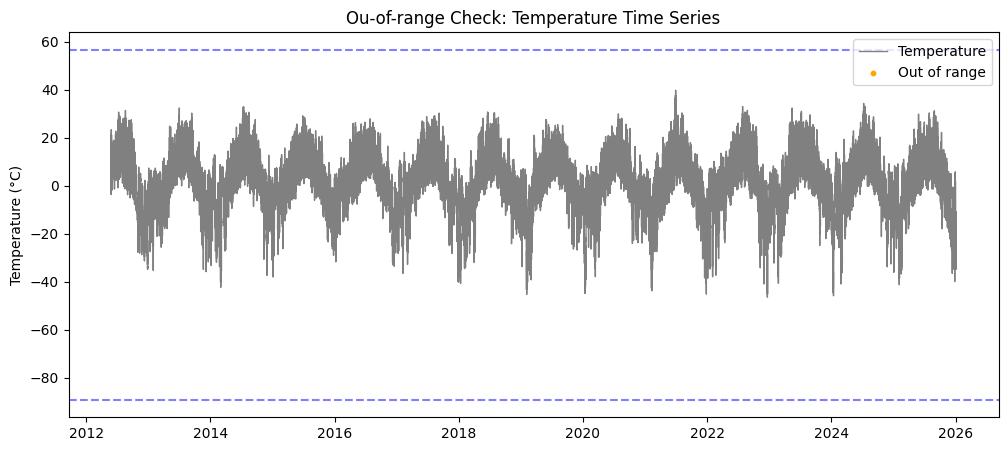

Out-of-range: 0


In [144]:
t_wmo_lowest = -89.2
t_wmo_highest = 56.7

t_sensor_lowest = -40
t_sensor_highest = 60


sensor_range_check = qc_range_check(df, min_val=t_sensor_lowest, max_val=t_sensor_highest)

wmo_range_check = qc_range_check(df, min_val=t_wmo_lowest, max_val=t_wmo_highest)

flag = wmo_range["flag"]
dev  = wmo_range["deviation"]
flag = wmo_range["flag"]
plot_out_range(df, min_val=t_wmo_lowest, max_val=t_wmo_highest, flag = flag)
print("Out-of-range:", flag.sum().values[0])

